In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from config.paths_config import *


In [2]:
import warnings
warnings.simplefilter("ignore")


### Data Loading and Preprocessing

In [3]:
df = pd.read_csv("train.csv")
df.head()
df.drop(columns=['Unnamed: 0', 'Booking_ID'] , inplace=True)
df.drop_duplicates(inplace=True)
df["booking_status"].value_counts()
data = df.copy()

In [4]:
df["booking_status"].value_counts()

booking_status
Not_Canceled    15231
Canceled         6128
Name: count, dtype: int64

#### Categorical and Numerical Columns 

In [5]:
cat_cols = ['type_of_meal_plan','required_car_parking_space',
       'room_type_reserved','market_segment_type', 'repeated_guest','booking_status']

num_cols = ['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights','lead_time', 'arrival_year', 'arrival_month',
       'arrival_date','no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests']

### EDA

#### Bivariate Analysis for numerical Data 

In [34]:

def plot_bivariate_num(df , target , num_features):
    num_plots = len(num_features)
    num_rows = (num_plots+1)//2

    fig , axes = plt.subplots(num_rows , 2 , figsize=(15 , num_rows*5))
    axes = axes.flatten()

    for i , column in enumerate(num_features):
        sns.boxplot(x=target,y=column,ax=axes[i] , data=df , palette="Blues")
        axes[i].set_title(f"{column}  VS {target}")

    plt.tight_layout()
    plt.show()

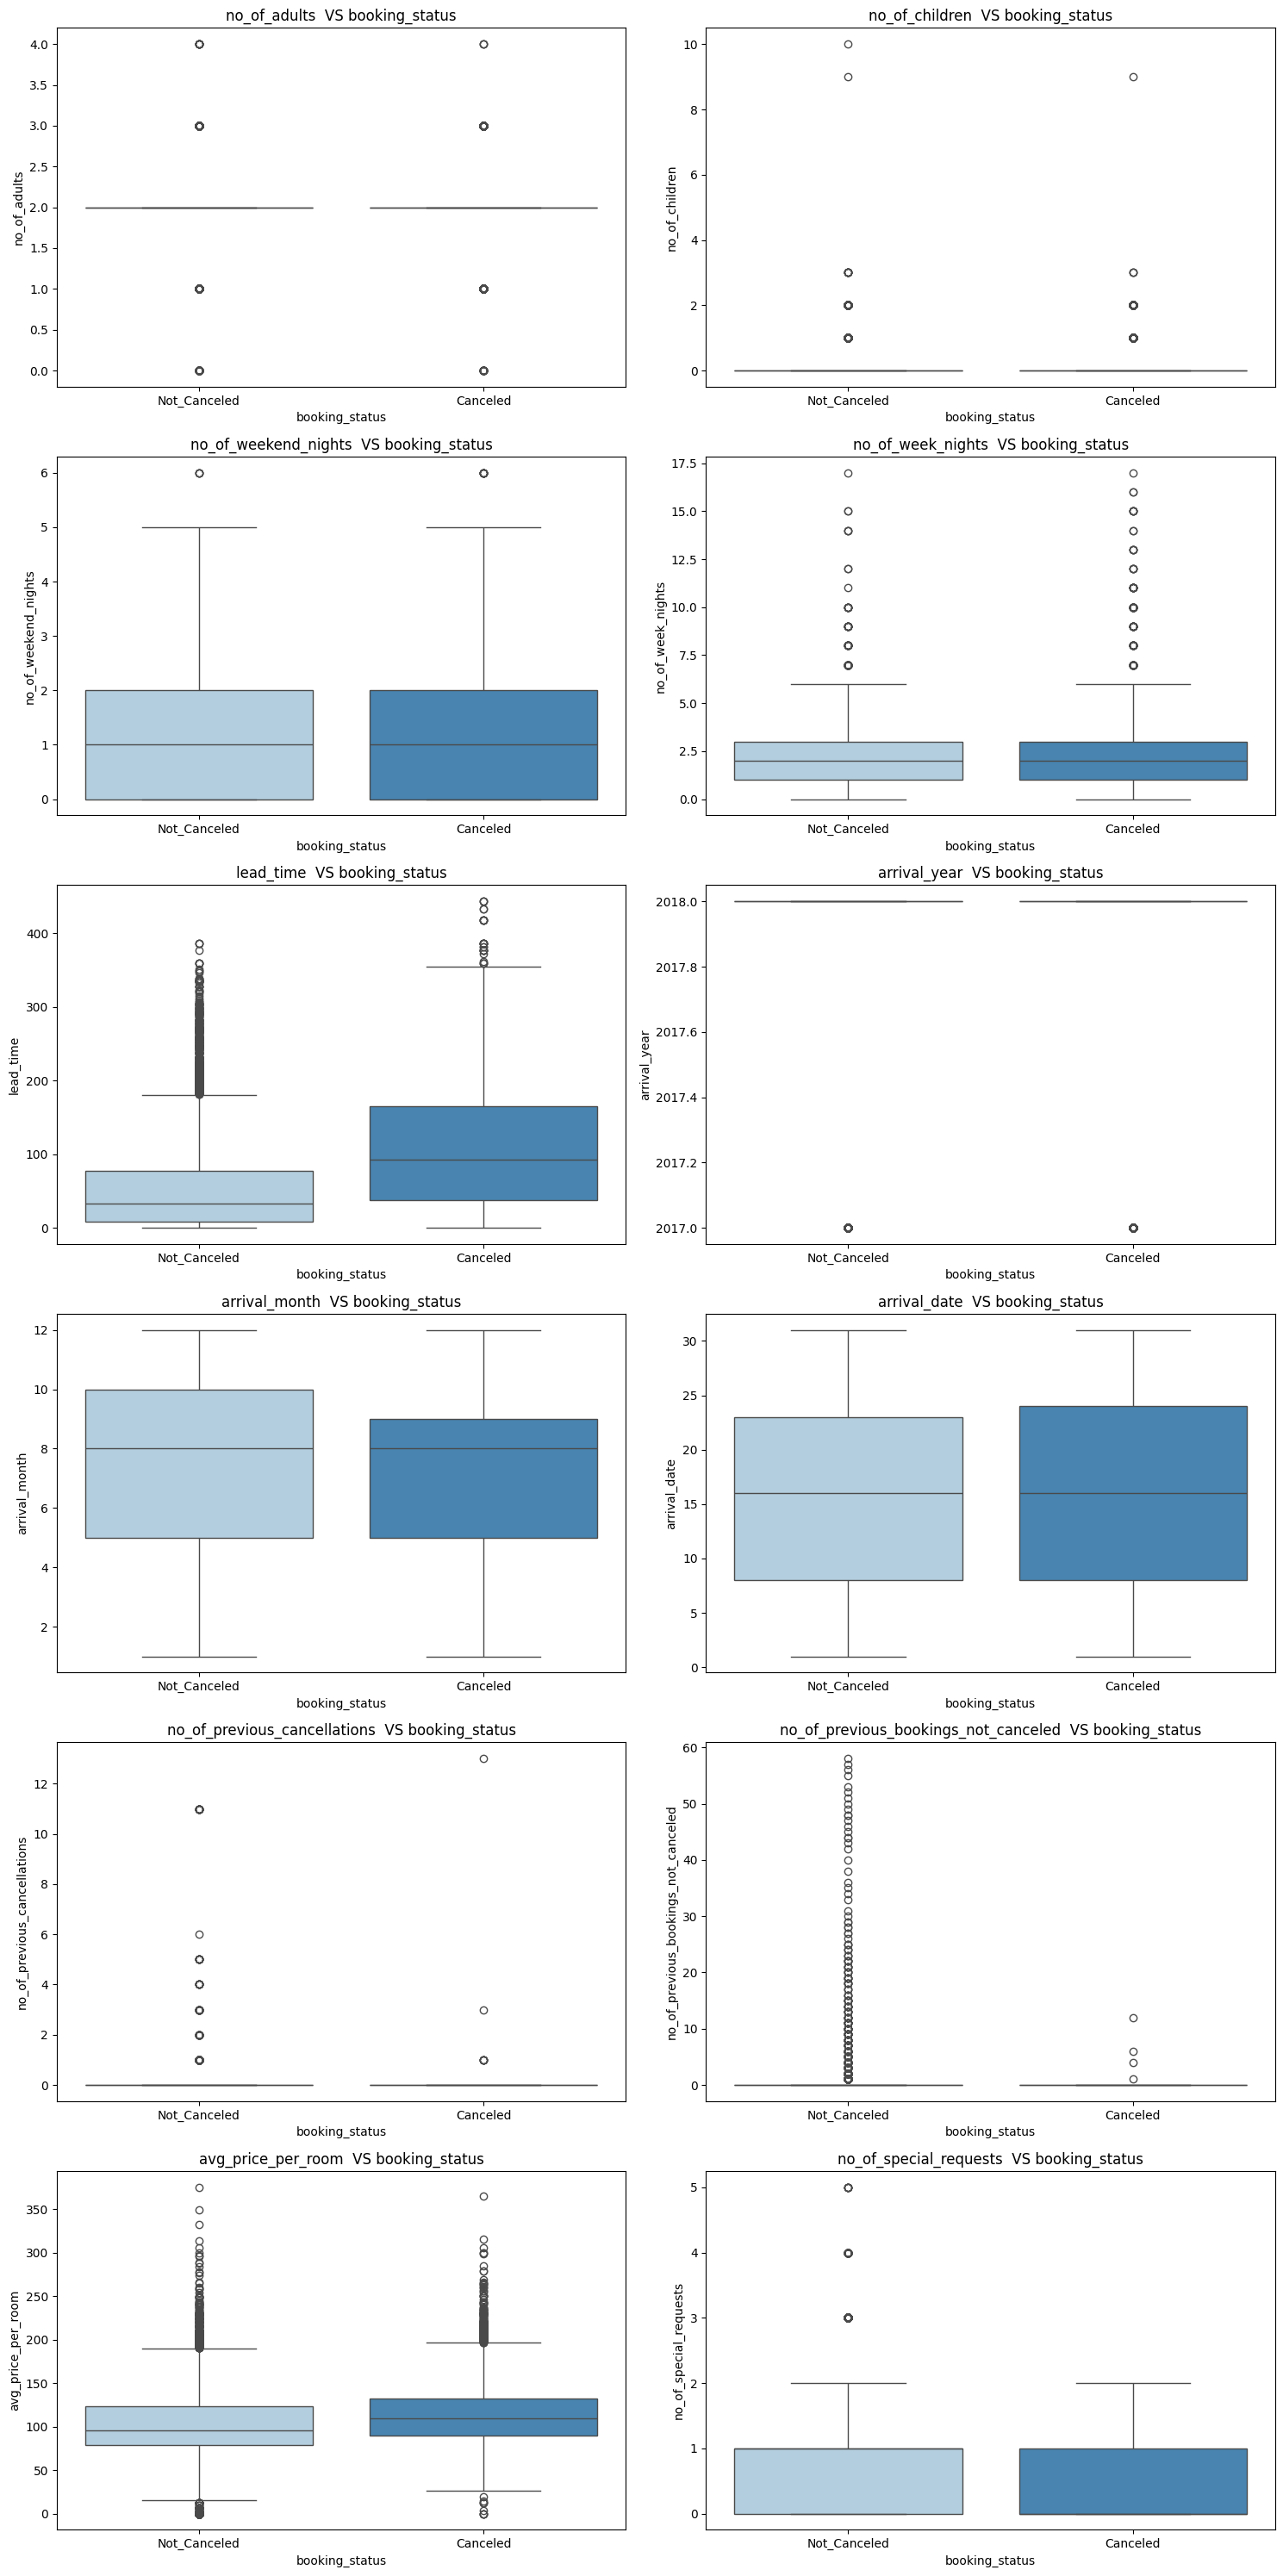

In [35]:
plot_bivariate_num(data , 'booking_status' , num_cols)

### Bivariate Analysis for Categorical Data 

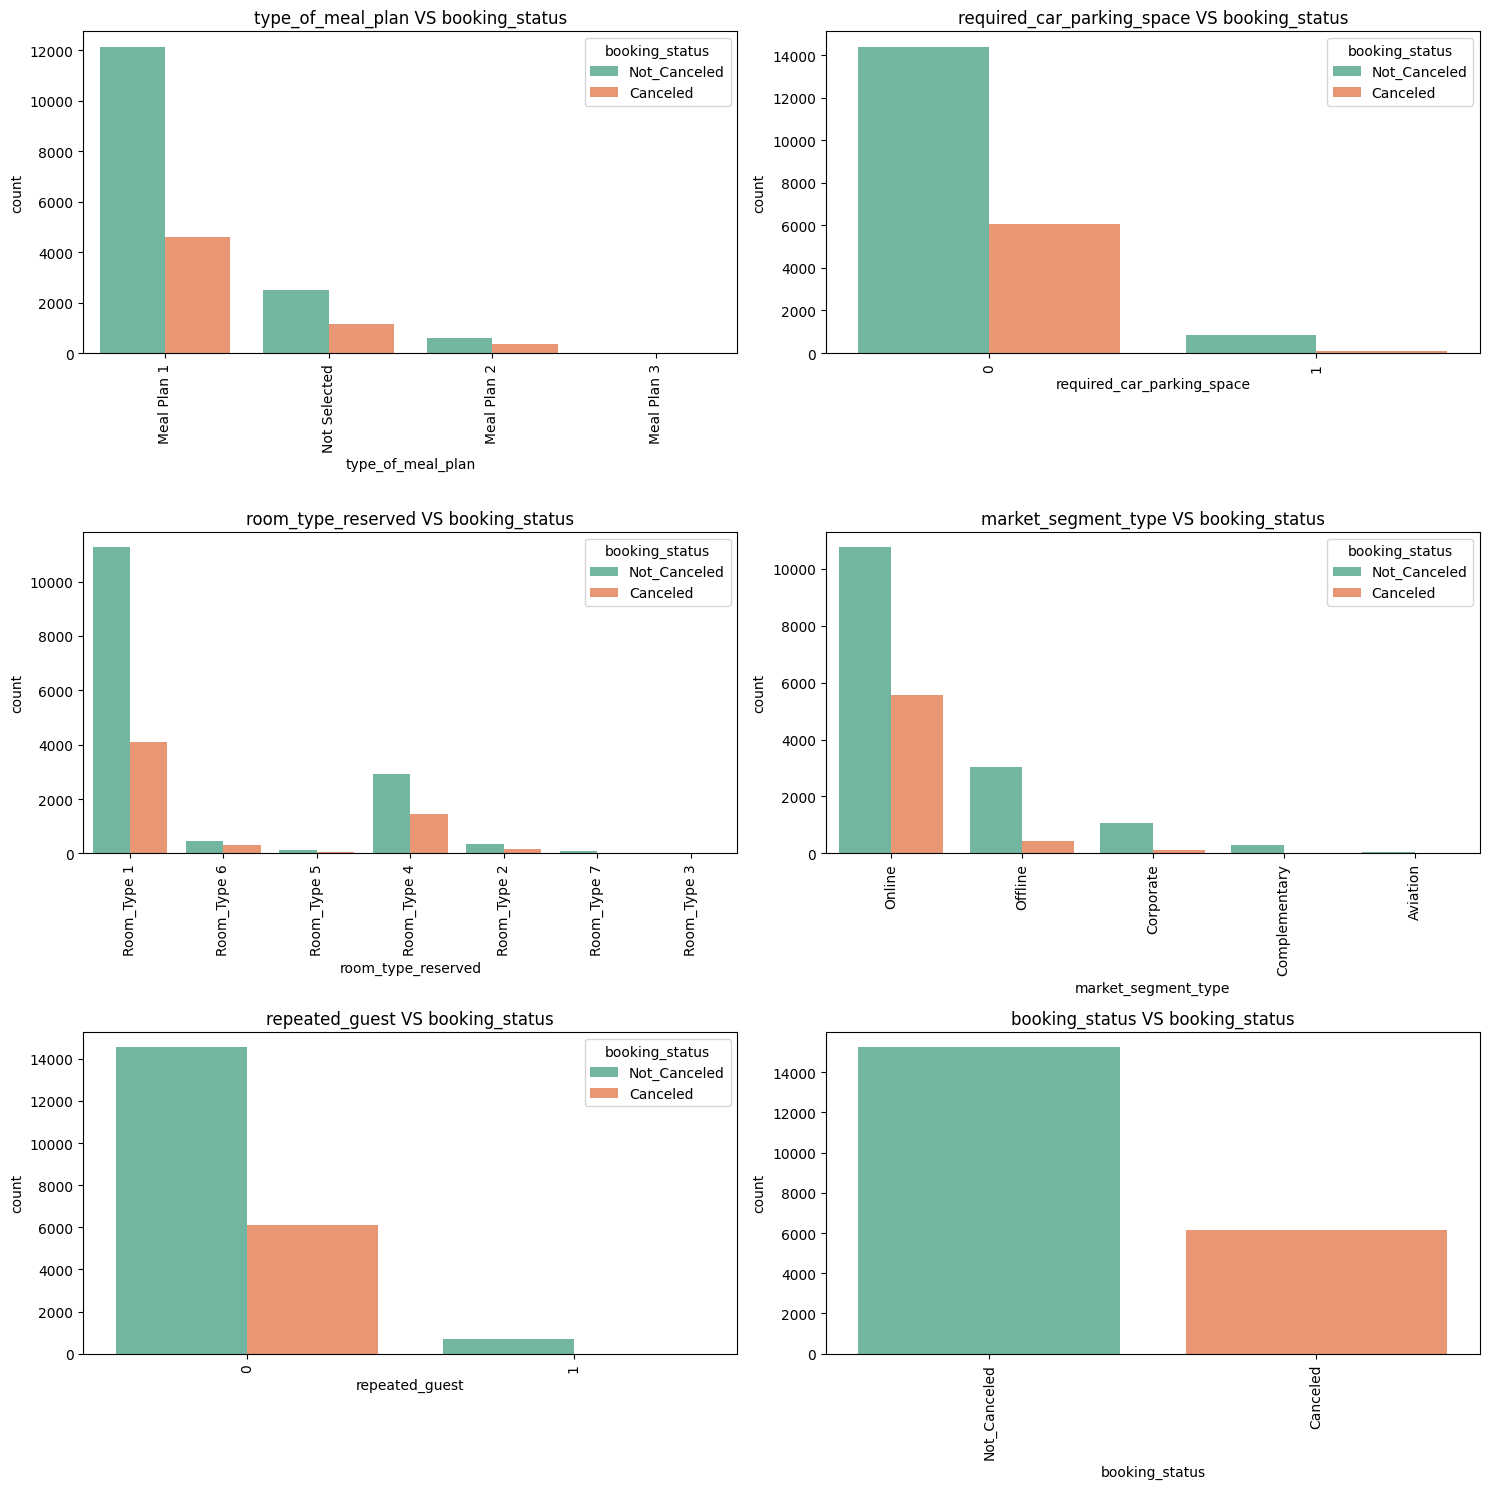

In [36]:
def plot_bivaraite_cat(df , target , cat_features):

    num_features = len(cat_features)
    num_rows = (num_features+1)//2

    fig , axes = plt.subplots(num_rows , 2 , figsize=(15 , num_rows*5))
    axes = axes.flatten()

    for i,feature in enumerate(cat_features):
        sns.countplot(x=feature , hue=target ,data=df , palette="Set2" , ax = axes[i])
        axes[i].set_title(f"{feature} VS {target}")
        axes[i].tick_params(axis='x' , rotation=90)

    plt.tight_layout()
    plt.show()

plot_bivaraite_cat(data , 'booking_status' , cat_cols)

### Data Processing

#### Labelling Every Categorical Features of the data 

In [ ]:
##### Label encoding
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

mappings={}

for col in cat_cols:
    df[col] = label_encoder.fit_transform(df[col])

    mappings[col] = {label:code for label,code in zip(label_encoder.classes_ , label_encoder.transform(label_encoder.classes_))}
    

In [7]:
mappings

{'type_of_meal_plan': {'Meal Plan 1': np.int64(0),
  'Meal Plan 2': np.int64(1),
  'Meal Plan 3': np.int64(2),
  'Not Selected': np.int64(3)},
 'required_car_parking_space': {np.int64(0): np.int64(0),
  np.int64(1): np.int64(1)},
 'room_type_reserved': {'Room_Type 1': np.int64(0),
  'Room_Type 2': np.int64(1),
  'Room_Type 3': np.int64(2),
  'Room_Type 4': np.int64(3),
  'Room_Type 5': np.int64(4),
  'Room_Type 6': np.int64(5),
  'Room_Type 7': np.int64(6)},
 'market_segment_type': {'Aviation': np.int64(0),
  'Complementary': np.int64(1),
  'Corporate': np.int64(2),
  'Offline': np.int64(3),
  'Online': np.int64(4)},
 'repeated_guest': {np.int64(0): np.int64(0), np.int64(1): np.int64(1)},
 'booking_status': {'Canceled': np.int64(0), 'Not_Canceled': np.int64(1)}}

#### Checing Multi Collinearity of the data
if VIF value of Any variable greater than 5 then it is multicollinear

In [44]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [45]:
X = add_constant(df)

vif_data = pd.DataFrame()

vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values,i) for i in range(X.shape[1])]

In [ ]:
vif_data ### any feature with VIF > 10 is considered to have high multicollinearity and may need to be removed or transformed.  

#### Checking Skewness of the data and applying log transformation to the features with skewness > 5

In [49]:
skewness  = df.skew()
for col in df.columns:
    if skewness[col] > 5:
        df[col] = np.log1p(df[col])

In [50]:
df["booking_status"].value_counts()
X = df.drop(columns='booking_status')
y = df["booking_status"]
y.value_counts()

booking_status
1    15231
0     6128
Name: count, dtype: int64

### Balancing the dataset using SMOTE

In [58]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_res , y_res = smote.fit_resample(X,y)
balanced_df = pd.DataFrame(X_res , columns=X.columns)
balanced_df["booking_status"] = y_res

### Getting Feature Importance of the data 

In [62]:
from sklearn.ensemble import RandomForestClassifier
X = df.drop(columns='booking_status')
y = df["booking_status"]
model =  RandomForestClassifier(random_state=42)
model.fit(X,y)
feature_importance = model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature':X.columns,
    'importance':feature_importance
})
top_features_importance_df = feature_importance_df.sort_values(by="importance" , ascending=False)
top_10_features = top_features_importance_df["feature"].head(10).values
top_10_df = df[top_10_features.tolist() + ["booking_status"]]


### Importing Libraries

In [64]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score

In [67]:
X = df.drop(columns='booking_status')
y = df["booking_status"]
X_train , X_test , y_train , y_test = train_test_split(X,y , test_size=0.2 , random_state=42)

### Defining Classifiers  

In [68]:
classifiers = {
    "Random Forest" : RandomForestClassifier(random_state=42),
    "LogisticRegression" : LogisticRegression(random_state=42),
    "Gradient Boosting" : GradientBoostingClassifier(random_state=42),
    "Suuport vector classifier" : SVC(random_state=42),
    "Decsion Tree" : DecisionTreeClassifier(random_state=42),
    "KNN" : KNeighborsClassifier(),
    "Naive Bayes" : GaussianNB(),
    "XGboost" : XGBClassifier(random_state=42),
    "Adaboost" : AdaBoostClassifier(random_state=42),
    "LGBM" : LGBMClassifier(random_state=42) 
}

metrics = {
    "Model" : [],
    "Accuracy" : [],
    "Precision" : [],
    "Recall" : [],
    "F1 Score" : []
}

#### Training all the classifier Models and storing the metrics in a dictionary to finally train the best accuracy model

In [ ]:
for model_name,classifier in classifiers.items():
    classifier.fit(X_train,y_train)

    y_pred = classifier.predict(X_test)

    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    recall = recall_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)

    metrics["Model"].append(model_name)
    metrics["Accuracy"].append(accuracy)
    metrics["Precision"].append(precision)
    metrics["Recall"].append(recall)
    metrics["F1 Score"].append(f1)

metrics_df = pd.DataFrame(metrics)

[LightGBM] [Info] Number of positive: 12230, number of negative: 4857
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010363 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 656
[LightGBM] [Info] Number of data points in the train set: 17087, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.715749 -> initscore=0.923471
[LightGBM] [Info] Start training from score 0.923471


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

X = df.drop(columns='booking_status')
y = df["booking_status"]

X_train , X_test , y_train , y_test = train_test_split(X,y , test_size=0.2 , random_state=42)
rf = RandomForestClassifier(random_state=42)

params_dist={
    'n_estimators' : randint(100,500),
    'max_depth' : randint(10,50),
    'min_samples_split': randint(2,10),
    'min_samples_leaf' : randint(1,5),
    'bootstrap' : [True , False] 
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=params_dist,
    n_iter=5,
    cv=5,
    verbose=2,
    random_state=42,
    scoring='accuracy'
)

random_search.fit(X_train,y_train)
best_rf_model = random_search.best_estimator_
y_pred = best_rf_model.predict(X_test)

In [79]:
random_search.fit(X_train,y_train)
best_rf_model = random_search.best_estimator_
y_pred = best_rf_model.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
[CV] END bootstrap=True, max_depth=38, min_samples_leaf=3, min_samples_split=4, n_estimators=171; total time=   3.9s
[CV] END bootstrap=True, max_depth=38, min_samples_leaf=3, min_samples_split=4, n_estimators=171; total time=   3.2s
[CV] END bootstrap=True, max_depth=38, min_samples_leaf=3, min_samples_split=4, n_estimators=171; total time=   3.2s
[CV] END bootstrap=True, max_depth=38, min_samples_leaf=3, min_samples_split=4, n_estimators=171; total time=   5.4s
[CV] END bootstrap=True, max_depth=38, min_samples_leaf=3, min_samples_split=4, n_estimators=171; total time=   6.9s
[CV] END bootstrap=True, max_depth=30, min_samples_leaf=3, min_samples_split=3, n_estimators=314; total time=   6.6s
[CV] END bootstrap=True, max_depth=30, min_samples_leaf=3, min_samples_split=3, n_estimators=314; total time=   5.4s
[CV] END bootstrap=True, max_depth=30, min_samples_leaf=3, min_samples_split=3, n_estimators=314; total time=   5.5s
[CV]